In [2]:
import re
import json
import nltk
import pandas as pd
import re
import unicodedata

In [3]:
nltk.download("punkt")
nltk.download("averaged_perceptron_tagger")
nltk.download("universal_tagset")

[nltk_data] Downloading package punkt to /Users/arocha/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/arocha/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package universal_tagset to
[nltk_data]     /Users/arocha/nltk_data...
[nltk_data]   Package universal_tagset is already up-to-date!


True

In [4]:
with open("constitutions.json", "r") as f:
    constitutions = json.load(f)

In [5]:
_WORD_NUMS = {
    'one':1,'two':2,'three':3,'four':4,'five':5,'six':6,'seven':7,
    'eight':8,'nine':9,'ten':10,'eleven':11,'twelve':12,'thirteen':13,
    'fourteen':14,'fifteen':15,'sixteen':16,'seventeen':17,'eighteen':18,
    'nineteen':19,'twenty':20,'thirty':30,'forty':40,'fifty':50,
    'sixty':60,'seventy':70,'eighty':80,'ninety':90,'hundred':100,
}

def _word_to_num(text):
    """Convert 'twenty three' → '23', leave rest alone."""
    tokens = text.lower().split()
    result, acc = [], 0
    for t in tokens:
        if t in _WORD_NUMS:
            acc += _WORD_NUMS[t]
        else:
            if acc:
                result.append(str(acc)); acc = 0
            result.append(t)
    if acc:
        result.append(str(acc))
    return ' '.join(result)


In [6]:
def roman_to_int(s):
    vals = {'I':1,'V':5,'X':10,'L':50,'C':100,'D':500,'M':1000}
    s = s.upper()
    total, prev = 0, 0
    for ch in reversed(s):
        v = vals.get(ch, 0)
        total += v if v >= prev else -v
        prev = v
    return total

In [7]:
_ARTICLE_ALIASES = re.compile(
    r'\b(art\.|arts\.|artículo|artikel|articolo|titre|título|titre|abschnitt|chapitre)\b',
    re.IGNORECASE
)
_SECTION_ALIASES = re.compile(
    r'\b(sec\.|sect\.|§+|sección|sezione|abschnitt|paragraphe|παρ\.?)\b',
    re.IGNORECASE
)
_CHAPTER_ALIASES = re.compile(
    r'\b(chap\.|chapitre|capítulo|capitolo|kapitel)\b',
    re.IGNORECASE
)
_PART_ALIASES = re.compile(
    r'\b(parte|partie|teil)\b',
    re.IGNORECASE
)
_TITLE_ALIASES = re.compile(
    r'\b(titre|título|titolo|titel)\b',
    re.IGNORECASE
)
_ROMAN = re.compile(r'\b([IVXLCDM]{1,10})\b')

def normalize_line(line):
    """
    Normalize a header line so a single set of regex patterns can match it.
    Returns the normalized line; original line is preserved elsewhere.
    """
    # 1. Unicode → ASCII where possible (handles accented chars, fancy dashes)
    line = unicodedata.normalize('NFKD', line)
    line = line.encode('ascii', 'ignore').decode('ascii')

    # 2. Collapse extra whitespace
    line = re.sub(r'\s+', ' ', line).strip()

    # 3. Alias → canonical keyword
    line = _ARTICLE_ALIASES.sub('Article', line)
    line = _SECTION_ALIASES.sub('Section', line)
    line = _CHAPTER_ALIASES.sub('Chapter', line)
    line = _PART_ALIASES.sub('Part', line)
    line = _TITLE_ALIASES.sub('Title', line)

    # 4. Roman numerals → Arabic (only in likely-header positions)
    def _rom_replace(m):
        word = m.group(1)
        n = roman_to_int(word)
        # sanity check: don't convert random all-caps words
        return str(n) if 1 <= n <= 500 else word
    line = _ROMAN.sub(_rom_replace, line)

    # 5. Word numbers → digits ("Article Twenty Three" → "Article 23")
    line = _word_to_num(line)

    return line

In [8]:
HEADER_PATTERNS = {
    "article": [
        r"^\s*(Article|Chapter|Part|Title)\s+\d+",
    ],
    "section": [
        r"^\s*Section\s+\d+",
        r"^\s*\d+\.",        # 1.
        r"^\s*\d+\)",        # 1)
    ],
    "subsection": [
        r"^\s*\([a-z]\)",    # (a)
        r"^\s*[a-z]\)",      # a)
        r"^\s*[a-z]\.",      # a.
        r"^\s*\(\d+\)",      # (1)
    ]
}


In [9]:
def classify_line(line):
    """Detect structural level using normalized line."""
    normalized = normalize_line(line)
    for level, patterns in HEADER_PATTERNS.items():
        for pat in patterns:
            if re.match(pat, normalized, re.IGNORECASE):
                return level
    return None

In [10]:
corpus_data = []

for country_id, text in constitutions.items():
    article_id = 0
    section_id = 0
    subsection_id = 0
    sent_global = 0

    for line in text.splitlines():
        line = line.strip()
        if not line:
            continue

        level = classify_line(line)

        # Update counters regardless — but DON'T skip the line
        if level == "article":
            article_id += 1
            section_id = 0
            subsection_id = 0
        elif level == "section":
            section_id += 1
            subsection_id = 0
        elif level == "subsection":
            subsection_id += 1

        # Tokenize every non-empty line, headers included
        sentences = nltk.sent_tokenize(line)

        for sentence in sentences:
            tokens = nltk.word_tokenize(sentence)
            pos_tags = nltk.pos_tag(tokens, tagset="universal")

            for token_id, (token_str, pos) in enumerate(pos_tags):
                term_str = re.sub(r"[\W_]+", "", token_str.lower())
                if not term_str:
                    continue

                corpus_data.append({
                    "country_id":   country_id,
                    "article_id":   article_id,
                    "section_id":   section_id,
                    "subsection_id": subsection_id,
                    "sent_id":      sent_global,
                    "token_id":     token_id,
                    "token_str":    token_str,
                    "term_str":     term_str,
                    "pos":          pos,
                    "pos_group":    pos,
                    "is_header":    level is not None,  # bonus: flag header tokens
                })

            sent_global += 1

In [11]:
CORPUS = pd.DataFrame(corpus_data)

CORPUS.set_index([
    "country_id",
    "article_id",
    "section_id",
    "subsection_id",
    "sent_id",
    "token_id"
], inplace=True)


CORPUS.head()

token_str  \
country_id       article_id section_id subsection_id sent_id token_id                
Afghanistan_2004 0          0          0             0       0         Afghanistan   
                                                             1                2004   
                                                     1       0            Preamble   
                                                     2       0               Share   
                                                     3       0                  In   

                                                                          term_str  \
country_id       article_id section_id subsection_id sent_id token_id                
Afghanistan_2004 0          0          0             0       0         afghanistan   
                                                             1                2004   
                                                     1       0            preamble   
                                                     2       0               share   
                                                     3       0                  in   

                                                                        pos  \
country_id       article_id section_id subsection_id sent_id token_id         
Afghanistan_2004 0          0          0             0       0          ADJ   
                                                             1          NUM   
                                                     1       0          ADJ   
                                                     2       0         NOUN   
                                                     3       0          ADP   

                                                                      pos_group  \
country_id       article_id section_id subsection_id sent_id token_id             
Afghanistan_2004 0          0          0             0       0              ADJ   
                                                             1              NUM   
                                                     1       0              ADJ   
                                                     2       0             NOUN   
                                                     3       0              ADP   

                                                                       is_header  
country_id       article_id section_id subsection_id sent_id token_id             
Afghanistan_2004 0          0          0             0       0             False  
                                                             1             False  
                                                     1       0             False  
                                                     2       0             False  
                                                     3       0             False

In [12]:
len(CORPUS)

4263565

In [13]:
structure_report = []

for country_id, group in CORPUS.groupby(level=0):

    idx = group.index

    structure_report.append({

        "country_id": country_id,

        "tokens": len(group),

        "articles":
            idx.get_level_values("article_id").nunique(),

        "sections":
            idx.get_level_values("section_id").nunique(),

        "subsections":
            idx.get_level_values("subsection_id").nunique(),

        "sentences":
            idx.get_level_values("sent_id").nunique(),
    })

STRUCTURE = pd.DataFrame(structure_report)

print("\n--- STRUCTURE REPORT ---\n")
print(STRUCTURE)


flat_docs = STRUCTURE[
    (STRUCTURE["articles"] <= 1) |
    (STRUCTURE["sections"] <= 1)
]

print("\n--- POSSIBLE PARSING FAILURES ---\n")

if flat_docs.empty:
    print("No obvious failures detected.")
else:
    print(flat_docs)




--- STRUCTURE REPORT ---

           country_id  tokens  articles  sections  subsections  sentences
0    Afghanistan_2004   10498       175        22            1        838
1        Albania_2008   13961       212         9           13       1534
2        Algeria_2008   10756       199        31            1        908
3        Andorra_1993    8793       128        12           13        823
4         Angola_2010   26408       272        10           24       2502
..                ...     ...       ...       ...          ...        ...
187      Vanuatu_1983    8467        20        49           12        794
188    Venezuela_2009   36670       393        34            1       2250
189        Yemen_2001   10898       170        19           11        882
190       Zambia_2009   30280       155        18           31       1832
191     Zimbabwe_2013   54741        81       117           21       4799

[192 rows x 6 columns]

--- POSSIBLE PARSING FAILURES ---

            country_id  t

In [14]:
STRUCTURE.head()

,country_id,tokens,articles,sections,subsections,sentences
0,Afghanistan_2004,10498,175,22,1,838
1,Albania_2008,13961,212,9,13,1534
2,Algeria_2008,10756,199,31,1,908
3,Andorra_1993,8793,128,12,13,823
4,Angola_2010,26408,272,10,24,2502


In [15]:
flat_docs

,country_id,tokens,articles,sections,subsections,sentences
26,Burkina_Faso_2012,10209,200,1,1,933
33,Chad_2005,11518,252,1,1,1112
37,Comoros_2009,6226,68,1,1,432
38,Congo_2001,11316,211,1,1,980
40,Cote_DIvoire_2009,8029,150,1,1,703
42,Cuba_2002,12888,153,1,25,844
60,France_2008,14473,146,1,1,868
81,Israel_2013,18294,1,299,14,1405
84,Japan_1946,5098,115,1,1,454
97,Libya_2011,2947,1,6,1,219


In [16]:
CORPUS.reset_index().to_csv(
    "const_TOKEN.csv",
    index=False
)

print("\nToken table saved.")


Token table saved.


In [17]:
import numpy as np

VOCAB = CORPUS.term_str.value_counts().to_frame('n').sort_index()
VOCAB.index.name = 'term_str'
VOCAB['n_chars'] = VOCAB.index.str.len()
VOCAB['p'] = VOCAB.n / VOCAB.n.sum()
VOCAB['i'] = -np.log2(VOCAB.p)
VOCAB


,n,n_chars,p,i
term_str,,,,
0,15,1,3.518183e-06,18.116738
00,6,2,1.407273e-06,19.438666
000,9,3,2.110910e-06,18.853704
00000,1,5,2.345455e-07,22.023629
005,1,3,2.345455e-07,22.023629
...,...,...,...,...
órgano,1,6,2.345455e-07,22.023629
órganos,1,7,2.345455e-07,22.023629
ô,1,1,2.345455e-07,22.023629


In [18]:
VOCAB['max_pos'] = CORPUS[['term_str','pos']].value_counts().unstack(fill_value=0).idxmax(1)
VOCAB['max_pos_group'] = CORPUS[['term_str','pos_group']].value_counts().unstack(fill_value=0).idxmax(1)
VOCAB

,n,n_chars,p,i,max_pos,max_pos_group
term_str,,,,,,
0,15,1,3.518183e-06,18.116738,NUM,NUM
00,6,2,1.407273e-06,19.438666,NUM,NUM
000,9,3,2.110910e-06,18.853704,NUM,NUM
00000,1,5,2.345455e-07,22.023629,NUM,NUM
005,1,3,2.345455e-07,22.023629,NUM,NUM
...,...,...,...,...,...,...
órgano,1,6,2.345455e-07,22.023629,ADJ,ADJ
órganos,1,7,2.345455e-07,22.023629,ADJ,ADJ
ô,1,1,2.345455e-07,22.023629,NOUN,NOUN


In [19]:
VOCAB['n_pos_group'] = CORPUS[['term_str','pos_group']].value_counts().unstack().count(1)
VOCAB['cat_pos_group'] = CORPUS[['term_str','pos_group']].value_counts().to_frame('n').reset_index()\
    .groupby('term_str').pos_group.apply(lambda x: set(x))
VOCAB['n_pos'] = CORPUS[['term_str','pos']].value_counts().unstack().count(1)
VOCAB['cat_pos'] = CORPUS[['term_str','pos']].value_counts().to_frame('n').reset_index()\
    .groupby('term_str').pos.apply(lambda x: set(x))

In [20]:
Q = VOCAB.groupby(VOCAB.n_pos >= 2).agg({'n': ['count','sum']})
Q = ((Q / Q.sum()) * 100).round().astype(int)
Q.columns = ['types', 'tokens']
Q.index = ['unambiguous','ambiguous']
Q.style.background_gradient()

,types,tokens
unambiguous,83,14
ambiguous,17,86


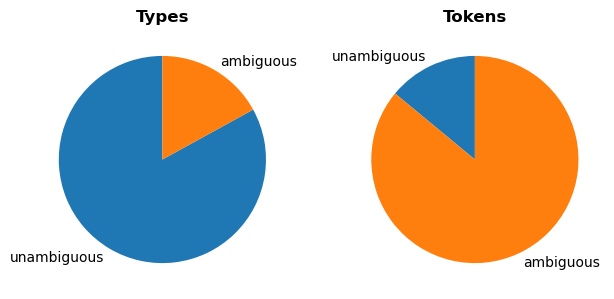

In [21]:
import matplotlib.pyplot as plt

ax = Q.plot.pie(subplots=True, legend=False, startangle=90)
ax[0].set_ylabel('')
ax[1].set_ylabel('')
ax[0].set_title('Types', fontweight='bold')
ax[1].set_title('Tokens', fontweight='bold')
plt.tight_layout()
plt.show()

In [22]:
nltk.download('stopwords')
sw = pd.DataFrame(nltk.corpus.stopwords.words('english'), columns=['term_str'])
sw = sw.reset_index().set_index('term_str')
sw.columns = ['dummy']
sw.dummy = 1
sw.sample(5)

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/arocha/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,dummy
term_str,
ve,1
there,1
most,1
she'd,1
m,1


In [23]:
VOCAB['stop'] = sw
VOCAB['stop'] = VOCAB['stop'].fillna(0).astype('int')

In [24]:
from nltk.stem.porter import PorterStemmer
stemmer1 = PorterStemmer()
VOCAB['stem_porter'] = VOCAB.apply(lambda x: stemmer1.stem(x.name), 1)

from nltk.stem.snowball import SnowballStemmer
stemmer2 = SnowballStemmer("english")
VOCAB['stem_snowball'] = VOCAB.apply(lambda x: stemmer2.stem(x.name), 1)

from nltk.stem.lancaster import LancasterStemmer
stemmer3 = LancasterStemmer()
VOCAB['stem_lancaster'] = VOCAB.apply(lambda x: stemmer3.stem(x.name), 1)

In [26]:
VOCAB.head()

,n,n_chars,p,i,max_pos,max_pos_group,n_pos_group,cat_pos_group,n_pos,cat_pos,stop,stem_porter,stem_snowball,stem_lancaster
term_str,,,,,,,,,,,,,,
0,15,1,3.518183e-06,18.116738,NUM,NUM,1,{NUM},1,{NUM},0,0,0,0
00,6,2,1.407273e-06,19.438666,NUM,NUM,1,{NUM},1,{NUM},0,00,00,00
000,9,3,2.110910e-06,18.853704,NUM,NUM,1,{NUM},1,{NUM},0,000,000,000
00000,1,5,2.345455e-07,22.023629,NUM,NUM,1,{NUM},1,{NUM},0,00000,00000,00000
005,1,3,2.345455e-07,22.023629,NUM,NUM,1,{NUM},1,{NUM},0,005,005,005


In [27]:
len(VOCAB)

39730

In [28]:
doc_terms = (
    CORPUS
    .reset_index()[['country_id', 'term_str']]
    .drop_duplicates()
)

# df = number of documents containing term
df = (
    doc_terms
    .groupby('term_str')
    .size()
    .rename('df')
)

In [29]:
N_docs = (
    CORPUS
    .reset_index()['country_id']
    .nunique()
)

In [30]:
VOCAB = VOCAB.join(df)

# fill missing df values
VOCAB['df'] = VOCAB['df'].fillna(0)


In [31]:
VOCAB['idf'] = np.log(N_docs / VOCAB['df'])

In [32]:
VOCAB['dfidf'] = VOCAB['df'] * VOCAB['idf']

In [33]:
VOCAB[['df', 'idf', 'dfidf']].sort_values(
    'dfidf',
    ascending=False
).head(20).index

Index(['thereby', 'remains', 'bin', 'greater', 'integral', 'delivered',
       'stage', 'holder', 'holders', 'honor', '169', '168', 'organized',
       'servants', 'occasion', 'autonomous', 'answer', 'confirm', 'assent',
       'copy'],
      dtype='object', name='term_str')

In [34]:
VOCAB.to_csv('const_VOCAB.csv')